<a href="https://colab.research.google.com/github/yeatescp01/INFO648/blob/main/Lesson_10/Instructor_INFO_648_LSN10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Random Forests

#  1. Supervised Machine Learning, Classification, and Random Forests


##What is a Random Forest?
A **Random Forest** is an ensemble learning model. If a Decision Tree is a single "expert," a Random Forest is a committee of experts. It combines the predictions of many individual decision trees to reach a single, more accurate result.

##How it Works: The "Forest" Strategy
**Bootstrap Aggregating (Bagging)**: The model creates many different versions of the dataset by randomly selecting rows (with replacement). Each tree sees a slightly different "slice" of the data.

**Feature Randomness**: When splitting a node, each tree is only allowed to look at a random subset of features (e.g., it might only look at Attendance and Study Hours but ignore GPA for that specific split). This ensures the trees don't all look the same.

##The Ensemble Vote: * For Classification: The forest takes a "majority vote" from all trees.

##For Regression: The forest calculates the "average" of all tree outputs.

##Why Random Forests are Superior to Single Trees
Prevents Overfitting: A single tree often "memorizes" noise. Because a forest averages many trees, the random errors cancel each other out.

High Stability: Small changes in the data might change one tree, but they won't change the entire forest.

Feature Importance: It can automatically rank which variables (like GPA or Attendance) were most useful for the prediction.

Random Forest Example: "The Committee"
Imagine we are predicting if a student will pass a certification. Instead of one tree making the call, we consult three:
```
[ Tree 1 ]               [ Tree 2 ]               [ Tree 3 ]
    Is GPA > 3.0?         Is Attendance > 80%?      Is Study Hours > 10?
     /        \              /           \            /          \
  [Pass]    [Fail]        [Pass]       [Fail]      [Pass]      [Fail]
     |                       |                        |
(Vote: PASS)            (Vote: FAIL)             (Vote: PASS)```


In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/cps_with_education_clean.csv')

In [3]:
df.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
0,197,2020,40,1350.0,43,1,23,Some College
1,224,2020,40,1310.0,64,2,23,Bachelor's
2,323,2020,40,1020.0,51,2,23,Graduate / Professional
3,324,2020,40,1350.0,52,1,23,Graduate / Professional
4,353,2020,50,1310.0,37,2,23,Some College


In [4]:
df.describe()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP
count,2.476180e+05,247618.000000,247618.000000,247618.000000,247618.000000,247618.000000,247618.000000
mean,2.896190e+06,2023.358068,43.011150,2045.742057,44.728542,1.415289,27.981920
std,1.572192e+06,1.217079,7.245386,1478.484148,12.432250,0.492773,16.316574
min,1.970000e+02,2020.000000,21.000000,1002.000000,15.000000,1.000000,1.000000
25%,1.536342e+06,2022.000000,40.000000,1270.000000,35.000000,1.000000,12.000000
50%,2.928244e+06,2023.000000,40.000000,1630.000000,44.000000,1.000000,28.000000
75%,4.228782e+06,2024.000000,45.000000,2300.000000,54.000000,2.000000,42.000000
max,5.553888e+06,2025.000000,80.000000,13258.230000,85.000000,2.000000,56.000000


In [5]:
model_df=df

In [6]:
high_pay=model_df['EARNWEEK2'].median()

In [7]:
high_pay

1630.0

## 2. Defining the Target Variable: high_earner

We create a target variable called high_earner by labeling individuals who earn above the median weekly earnings as 1 and those at or below the median as 0. This converts a continuous income variable into a binary outcome that is suitable for classification.

Because high_earner can only take the values 0 or 1, it is a categorical target, not a numeric one, even though it is represented using numbers.

high\_earner =
\begin{cases}
1 & \text{if } \text{EARNWEEK2} > \text{median(EARNWEEK2)} \\
0 & \text{otherwise}
\end{cases}

In [8]:
model_df['high_earner']=(model_df['EARNWEEK2']>high_pay).astype(int)

In [9]:
model_df.head(15)

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education,high_earner
0,197,2020,40,1350.0,43,1,23,Some College,0
1,224,2020,40,1310.0,64,2,23,Bachelor's,0
2,323,2020,40,1020.0,51,2,23,Graduate / Professional,0
3,324,2020,40,1350.0,52,1,23,Graduate / Professional,0
4,353,2020,50,1310.0,37,2,23,Some College,0
5,362,2020,50,1210.0,53,2,23,Graduate / Professional,0
6,452,2020,60,1600.0,69,1,23,Master's,0
7,484,2020,50,2885.0,60,1,23,Graduate / Professional,1
8,493,2020,40,1080.0,56,1,23,Bachelor's,0
9,632,2020,40,1580.0,58,1,23,Associate's,0


In [10]:
model_df['high_earner'].value_counts()

,count
high_earner,
0,125077
1,122541


In [11]:
from sklearn.model_selection import train_test_split
#Which ones go into the features and which go into the target?
#"AGE", "UHRSWORKT", "AGE", "UHRSWORKT","high_earner"
X = model_df[["AGE", "UHRSWORKT","SEX","education"]]
y = model_df["high_earner"]




In [ ]:
y

## 3. Train–Test Split

The train–test split divides the data into two separate sets: one used to train the model and one used to evaluate it. The model is allowed to learn only from the training data, while the test data is kept hidden until evaluation.

This separation helps us estimate how well the model will perform on new, unseen data and prevents us from overestimating model performance.





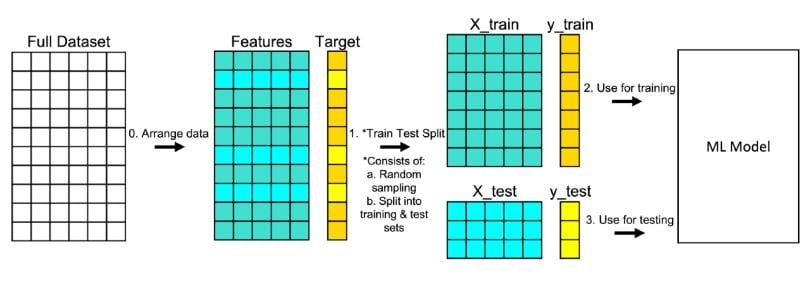

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

We use the following features to predict whether someone is a high earner:

features = ["AGE", "UHRSWORKT", "education", "SEX"]


* AGE – numeric (continuous)

* UHRSWORKT (usual hours worked per week) – numeric (continuous)

* education – categorical (levels of educational attainment)

* SEX – categorical

**Because our features include both numeric and categorical data, they must be processed differently before being used in a machine learning model.**

In [13]:
#which go into numeric and which go into categorical

#"AGE", "UHRSWORKT","education", "SEX"
numeric_features = [ "AGE", "UHRSWORKT","STATEFIP"]
categorical_features = [ "SEX","education"]


## Why We Scale Numeric Features

<font color='red'><b>We do not need to scale with forests*</b></font>



## One-Hot Encoding

<font color='red'><b>We do not need to one hot encode with forests - but we do with sklearn*</b></font>

Logistic regression requires numeric inputs and cannot directly interpret categorical values. One-hot encoding converts each category into a separate binary indicator variable:

x =
\begin{cases}
1 & \text{if the observation belongs to category } k \\
0 & \text{otherwise}
\end{cases}


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
#numeric_features
#categorical_features
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),categorical_features) #what goes here???)
    ],
    remainder='passthrough' # This keeps the numerical columns as they are
)

## What a Pipeline Does in scikit-learn

A pipeline combines preprocessing steps and the machine learning model into a single workflow. This ensures that all transformations learned from the training data are applied consistently to the test data.

Pipelines help prevent data leakage, simplify code, and reflect how models are built and deployed in real-world applications.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier   # <-- new import
from sklearn.ensemble import HistGradientBoostingClassifier

model = Pipeline([
    ("prep", preprocess),
    ("clf", HistGradientBoostingClassifier(
        max_iter=300,         # number of trees
        #n_estimators=300,
        max_depth=20,          # same idea as tree depth
        min_samples_leaf=20,   # minimum leaf size
        random_state=42        # reproducibility
    ))
])



In [25]:
#This time we will type the code to fit the model
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SEX', 'education'])])),
                ('clf',
                 HistGradientBoostingClassifier(max_depth=20, max_iter=300,
                                                random_state=42))])

In [17]:
importances=model.named_steps['clf'].feature_importances_
import pandas as pd

# Get the feature names after preprocessing
transformed_feature_names = model.named_steps['prep'].get_feature_names_out()

feat_imp = pd.Series(importances, index=transformed_feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

feat_imp

,0
remainder__AGE,0.204725
cat__education_Graduate / Professional,0.193562
remainder__UHRSWORKT,0.149510
cat__education_Master's,0.130515
cat__education_Some College,0.114353
cat__SEX_2,0.054976
cat__SEX_1,0.048876
cat__education_Associate's,0.042328
cat__education_Bachelor's,0.037534
cat__education_Less than HS,0.019512


## What model.fit() Does

Calling model.fit() trains the entire pipeline using the training data. During this step, preprocessing parameters (such as scaling ranges and category mappings) are learned, and the logistic regression model estimates its coefficients.

All learning occurs only on the training set, preserving the integrity of model evaluation.

In [26]:
#this time we will run the prediction against the test data
y_pred=model.predict(X_test)

| Actual \\ Predicted | Predicted 0 (Negative) | Predicted 1 (Positive) |
|--------------------|------------------------|------------------------|
| **Actual 0 (Negative)** | True Negative (TN) | False Positive (FP) |
| **Actual 1 (Positive)** | False Negative (FN) | True Positive (TP) |


___________________________________________
___________________________________________

| Actual \\ Predicted | Not High Earner (0) | High Earner (1) |
|--------------------|--------------------|----------------|
| **Not High Earner (0)** | True Negative (TN) | False Positive (FP) |
| **High Earner (1)** | False Negative (FN) | True Positive (TP) |



In [27]:
from sklearn.metrics import confusion_matrix, classification_report
#Actual first
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[20832 10438]
 [11011 19624]]
              precision    recall  f1-score   support

           0       0.65      0.67      0.66     31270
           1       0.65      0.64      0.65     30635

    accuracy                           0.65     61905
   macro avg       0.65      0.65      0.65     61905
weighted avg       0.65      0.65      0.65     61905



Can we make the model better by tuning the model (changing splits and leaves and such). Will changing the threshold help us get those big donors??

# We want to determine if our model has high variance or high bias.
## We also want to determine what the best threshold is:
We will use Youden's_j which is the maximum value between TPR and FPR (high true positiv and low false positive):
$$J=TPR−FPR$$

Below provides a visual concept:

# This is the code that provides the AUC - the closer to 1 the better the AUC.

In [28]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_curve, roc_auc_score
proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
print(auc)

0.7079277085090872


# This is the code to find Youden's J

In [29]:
import numpy as np
j_scores = tpr - fpr#Maximize Goods-Bads
best_threshold = thresholds[np.argmax(j_scores)]
best_threshold

np.float64(0.48469053045258964)

# The below code draws the ROC Curve

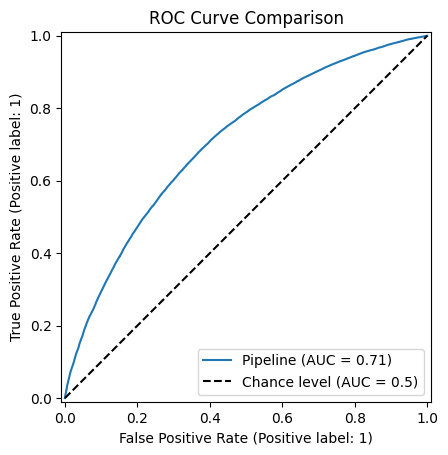

In [30]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# 1. Plot the model and the diagonal chance level (0.5 AUC)
RocCurveDisplay.from_estimator(model, X_test, y_test, plot_chance_level=True)

# 2. Add a title (optional but good for students)
plt.title("ROC Curve Comparison")
plt.show()

In [31]:
#Let's change the cut off to 0.48 and see if that matters
y_pred_Num = (proba >= 0.48).astype(int)
print(confusion_matrix(y_test, y_pred_Num))
print(classification_report(y_test, y_pred_Num, digits=3))

[[18988 12282]
 [ 9157 21478]]
              precision    recall  f1-score   support

           0      0.675     0.607     0.639     31270
           1      0.636     0.701     0.667     30635

    accuracy                          0.654     61905
   macro avg      0.655     0.654     0.653     61905
weighted avg      0.656     0.654     0.653     61905

